#  Flight Fare Prediction — EDA & Model Analysis

**Dataset:** Flight Price Dataset of Bangladesh  
**Task:** Supervised Regression — Predict Total Fare  


---

## 1. Imports & Configuration

In [ ]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 130, 'axes.titlesize': 13, 'axes.titleweight': 'bold'})

PROJECT_ROOT = Path.cwd().parent
DATA_PATH    = PROJECT_ROOT / 'data' / 'Flight_Price_Dataset_of_Bangladesh.csv'

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at: {DATA_PATH}\n"
        
    )

RANDOM_STATE = 42
TEST_SIZE    = 0.2

print(f'Dataset found at: {DATA_PATH}')


Dataset found at: /home/pazzoti/de-upskilling/flight-fare-prediction-using-ml/data/Flight_Price_Dataset_of_Bangladesh.csv
All imports successful.


## 2. Data Loading & Initial Inspection

In [ ]:
df_raw = pd.read_csv(DATA_PATH)
print(f'Shape   : {df_raw.shape}')
print(f'Columns : {list(df_raw.columns)}')
df_raw.head(3)

Shape   : (57000, 17)
Columns : ['Airline', 'Source', 'Source Name', 'Destination', 'Destination Name', 'Departure Date & Time', 'Arrival Date & Time', 'Duration (hrs)', 'Stopovers', 'Aircraft Type', 'Class', 'Booking Source', 'Base Fare (BDT)', 'Tax & Surcharge (BDT)', 'Total Fare (BDT)', 'Seasonality', 'Days Before Departure']


,Airline,Source,Source Name,Destination,Destination Name,Departure Date & Time,Arrival Date & Time,Duration (hrs),Stopovers,Aircraft Type,Class,Booking Source,Base Fare (BDT),Tax & Surcharge (BDT),Total Fare (BDT),Seasonality,Days Before Departure
0,Malaysian Airlines,CXB,Cox's Bazar Airport,CCU,Netaji Subhas Chandra Bose International Airpo...,2025-11-17 06:25:00,2025-11-17 07:38:10,1.219526,Direct,Airbus A320,Economy,Online Website,21131.225021,5169.683753,26300.908775,Regular,10
1,Cathay Pacific,BZL,Barisal Airport,CGP,"Shah Amanat International Airport, Chittagong",2025-03-16 00:17:00,2025-03-16 00:53:31,0.608638,Direct,Airbus A320,First Class,Travel Agency,11605.395471,200.000000,11805.395471,Regular,14
2,British Airways,ZYL,"Osmani International Airport, Sylhet",KUL,Kuala Lumpur International Airport,2025-12-13 12:03:00,2025-12-13 14:44:22,2.689651,1 Stop,Boeing 787,Economy,Travel Agency,39882.499349,11982.374902,51864.874251,Winter Holidays,83


In [ ]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57000 entries, 0 to 56999
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Airline                57000 non-null  object 
 1   Source                 57000 non-null  object 
 2   Source Name            57000 non-null  object 
 3   Destination            57000 non-null  object 
 4   Destination Name       57000 non-null  object 
 5   Departure Date & Time  57000 non-null  object 
 6   Arrival Date & Time    57000 non-null  object 
 7   Duration (hrs)         57000 non-null  float64
 8   Stopovers              57000 non-null  object 
 9   Aircraft Type          57000 non-null  object 
 10  Class                  57000 non-null  object 
 11  Booking Source         57000 non-null  object 
 12  Base Fare (BDT)        57000 non-null  float64
 13  Tax & Surcharge (BDT)  57000 non-null  float64
 14  Total Fare (BDT)       57000 non-null  float64
 15  Se

In [ ]:
df_raw.describe(include='all').round(2)

,Airline,Source,Source Name,Destination,Destination Name,Departure Date & Time,Arrival Date & Time,Duration (hrs),Stopovers,Aircraft Type,Class,Booking Source,Base Fare (BDT),Tax & Surcharge (BDT),Total Fare (BDT),Seasonality,Days Before Departure
count,57000,57000,57000,57000,57000,57000,57000,57000.00,57000,57000,57000,57000,57000.00,57000.00,57000.00,57000,57000.00
unique,24,8,8,20,20,54126,56944,NaN,3,5,3,3,NaN,NaN,NaN,4,NaN
top,US-Bangla Airlines,CGP,"Shah Amanat International Airport, Chittagong",JED,"King Abdulaziz International Airport, Jeddah",2025-11-15 15:33:00,2025-12-10 21:54:33,NaN,Direct,Airbus A320,Economy,Direct Booking,NaN,NaN,NaN,Regular,NaN
freq,4496,7241,7241,3071,3071,4,2,NaN,36642,23970,19112,19111,NaN,NaN,NaN,44525,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.99,NaN,NaN,NaN,NaN,58899.56,11448.24,71030.32,NaN,45.46
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.09,NaN,NaN,NaN,NaN,68840.61,12124.34,81769.20,NaN,26.02
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.50,NaN,NaN,NaN,NaN,1600.98,200.00,1800.98,NaN,1.00
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.00,NaN,NaN,NaN,NaN,8856.32,200.00,9602.70,NaN,23.00
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.64,NaN,NaN,NaN,NaN,31616.00,9450.94,41307.54,NaN,45.00
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.49,NaN,NaN,NaN,NaN,85722.93,17513.05,103800.91,NaN,68.00


In [ ]:
missing     = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct}).query('`Missing Count` > 0')

,Missing Count,Missing %


## 3. Data Cleaning

In [ ]:
df = df_raw.copy()

df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
df = df.loc[:, ~df.columns.duplicated()]

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(r'[\s&/\-\(\)]+', '_', regex=True)
    .str.replace(r'_+', '_', regex=True)
    .str.strip('_')
)

df.rename(columns={
    'base_fare_bdt':       'base_fare',
    'tax_surcharge_bdt':   'tax_surcharge',
    'total_fare_bdt':      'total_fare',
    'departure_date_time': 'departure_dt',
    'arrival_date_time':   'arrival_dt',
    'duration_hrs':        'duration',
}, inplace=True)

print('Columns after normalization:')
print(list(df.columns))

Columns after normalization:
['airline', 'source', 'source_name', 'destination', 'destination_name', 'departure_dt', 'arrival_dt', 'duration', 'stopovers', 'aircraft_type', 'class', 'booking_source', 'base_fare', 'tax_surcharge', 'total_fare', 'seasonality', 'days_before_departure']


In [ ]:
for col in ['base_fare', 'tax_surcharge', 'total_fare', 'duration', 'days_before_departure']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

for col in ['departure_dt', 'arrival_dt']:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

if 'total_fare' not in df.columns:
    df['total_fare'] = df['base_fare'] + df['tax_surcharge']

num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

for col in ['base_fare', 'total_fare', 'tax_surcharge']:
    if col in df.columns:
        df = df[df[col] >= 0]

if 'base_fare' in df.columns and 'total_fare' in df.columns:
    df = df[df['base_fare'] <= df['total_fare']]

if 'airline' in df.columns:
    df['airline'] = df['airline'].str.strip().str.title()

for col in ['source_name', 'destination_name']:
    if col in df.columns:
        df[col] = df[col].str.strip().str.title()

df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

print(f'Raw shape        : {df_raw.shape}')
print(f'Cleaned shape    : {df.shape}')
print(f'Rows removed     : {df_raw.shape[0] - df.shape[0]}')
print(f'Missing remaining: {df.isnull().sum().sum()}')

Raw shape        : (57000, 17)
Cleaned shape    : (57000, 17)
Rows removed     : 0
Missing remaining: 0


## 4. Feature Engineering

In [ ]:
if 'departure_dt' in df.columns:
    df['month']   = df['departure_dt'].dt.month
    df['day']     = df['departure_dt'].dt.day
    df['weekday'] = df['departure_dt'].dt.weekday
    df['hour']    = df['departure_dt'].dt.hour

if 'departure_dt' in df.columns and 'arrival_dt' in df.columns:
    df['flight_duration_min'] = (
        (df['arrival_dt'] - df['departure_dt'])
        .dt.total_seconds()
        .div(60)
        .round(2)
    )

df.drop(columns=['departure_dt', 'arrival_dt', 'source', 'destination'], errors='ignore', inplace=True)

def assign_season(m):
    if m in [12, 1, 2]:  return 'winter'
    elif m in [3, 4, 5]: return 'spring'
    elif m in [6, 7, 8]: return 'summer'
    return 'autumn'

if 'month' in df.columns:
    df['season_derived'] = df['month'].apply(assign_season)

print(f'Features after engineering: {list(df.columns)}')
df.head(3)

Features after engineering: ['airline', 'source_name', 'destination_name', 'duration', 'stopovers', 'aircraft_type', 'class', 'booking_source', 'base_fare', 'tax_surcharge', 'total_fare', 'seasonality', 'days_before_departure', 'month', 'day', 'weekday', 'hour', 'flight_duration_min', 'season_derived']


,airline,source_name,destination_name,duration,stopovers,aircraft_type,class,booking_source,base_fare,tax_surcharge,total_fare,seasonality,days_before_departure,month,day,weekday,hour,flight_duration_min,season_derived
0,Malaysian Airlines,Cox'S Bazar Airport,Netaji Subhas Chandra Bose International Airpo...,1.219526,Direct,Airbus A320,Economy,Online Website,21131.225021,5169.683753,26300.908775,Regular,10,11,17,0,6,73.17,autumn
1,Cathay Pacific,Barisal Airport,"Shah Amanat International Airport, Chittagong",0.608638,Direct,Airbus A320,First Class,Travel Agency,11605.395471,200.000000,11805.395471,Regular,14,3,16,6,0,36.52,spring
2,British Airways,"Osmani International Airport, Sylhet",Kuala Lumpur International Airport,2.689651,1 Stop,Boeing 787,Economy,Travel Agency,39882.499349,11982.374902,51864.874251,Winter Holidays,83,12,13,5,12,161.37,winter


## 5. Exploratory Data Analysis

### 5.1 Total Fare Distribution

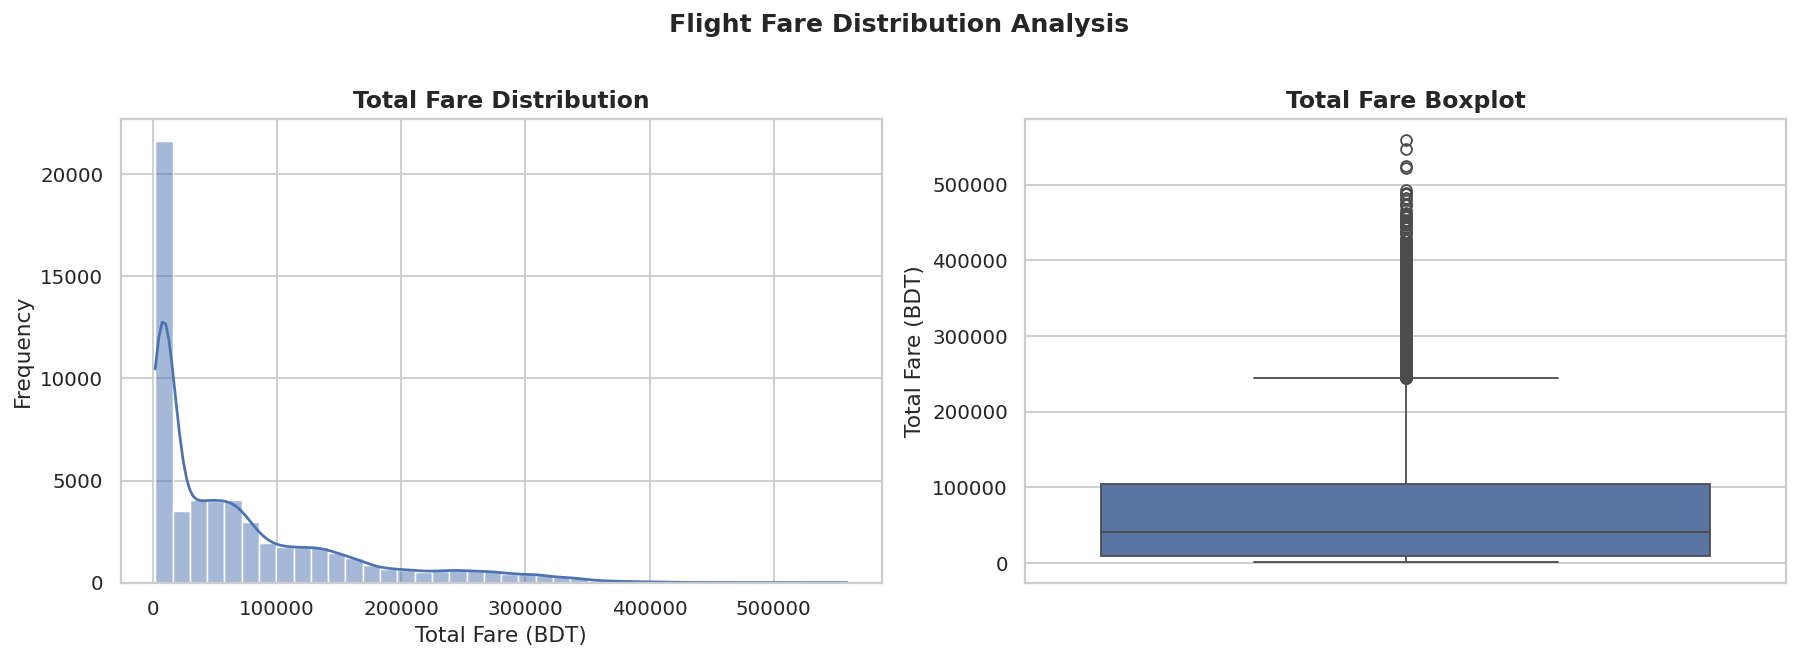

Mean   : 71,030.32 BDT
Median : 41,307.54 BDT
Std    : 81,769.20 BDT
Min    : 1,800.98 BDT
Max    : 558,987.33 BDT


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['total_fare'], bins=40, kde=True, color='#4C72B0', ax=axes[0])
axes[0].set_title('Total Fare Distribution')
axes[0].set_xlabel('Total Fare (BDT)')
axes[0].set_ylabel('Frequency')

sns.boxplot(y=df['total_fare'], color='#4C72B0', ax=axes[1])
axes[1].set_title('Total Fare Boxplot')
axes[1].set_ylabel('Total Fare (BDT)')

plt.suptitle('Flight Fare Distribution Analysis', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f"Mean   : {df['total_fare'].mean():,.2f} BDT")
print(f"Median : {df['total_fare'].median():,.2f} BDT")
print(f"Std    : {df['total_fare'].std():,.2f} BDT")
print(f"Min    : {df['total_fare'].min():,.2f} BDT")
print(f"Max    : {df['total_fare'].max():,.2f} BDT")

### 5.2 Average Fare by Airline

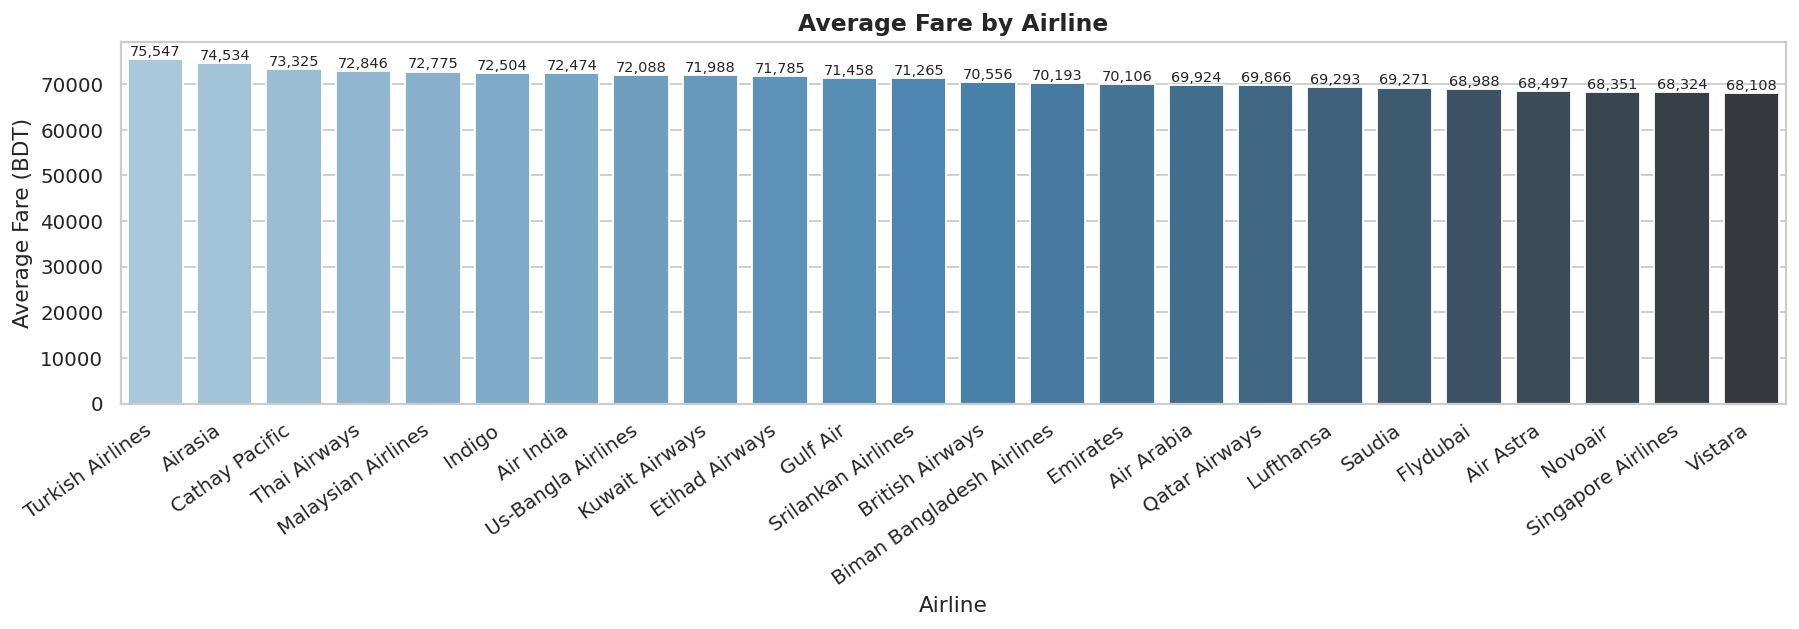

In [ ]:
avg_by_airline = (
    df.groupby('airline')['total_fare']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 5))
sns.barplot(data=avg_by_airline, x='airline', y='total_fare', palette='Blues_d', ax=ax)

for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 50,
        f"{bar.get_height():,.0f}",
        ha='center', va='bottom', fontsize=8
    )

ax.set_title('Average Fare by Airline')
ax.set_xlabel('Airline')
ax.set_ylabel('Average Fare (BDT)')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

### 5.3 Fare by Travel Class

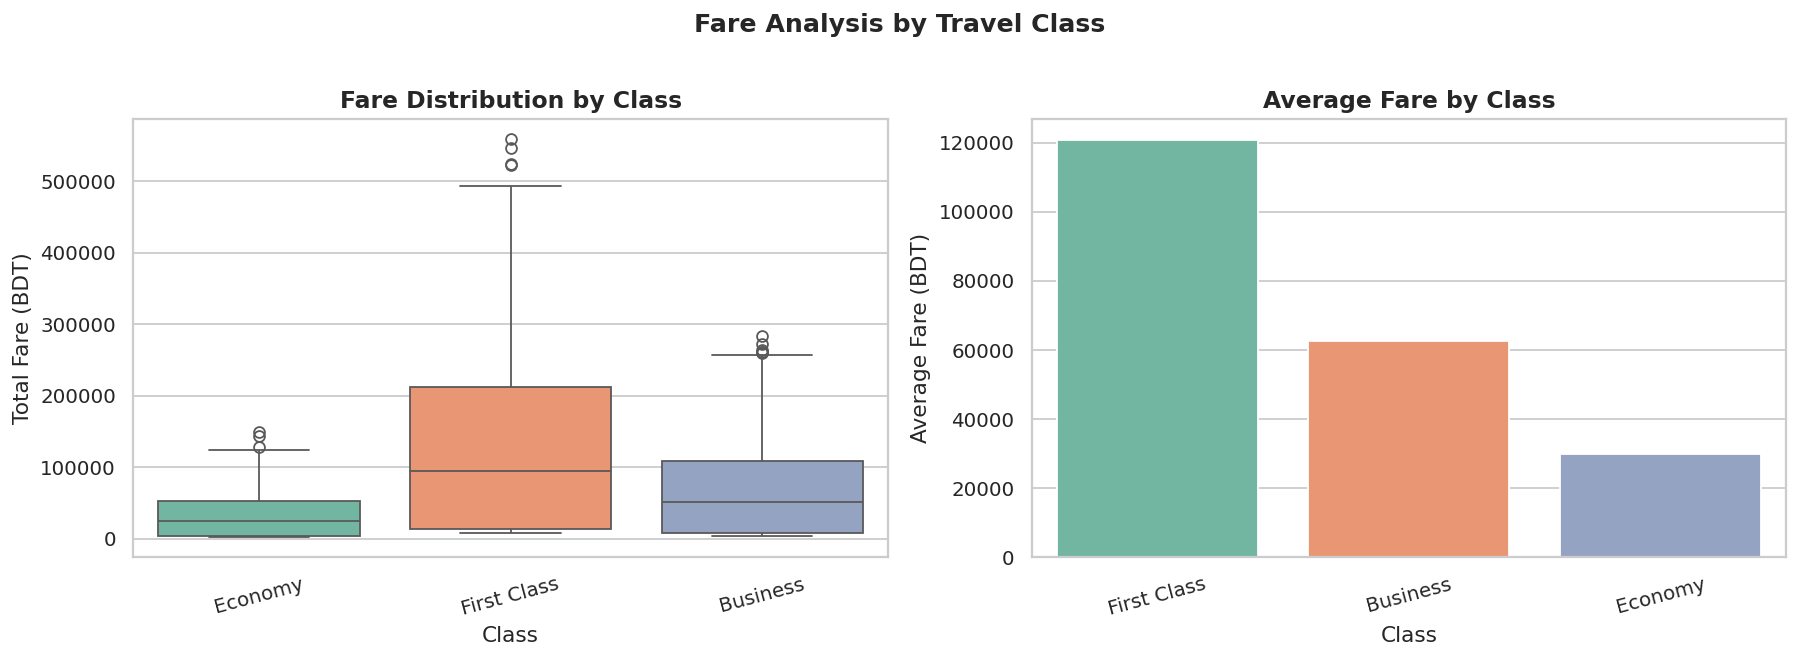

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='class', y='total_fare', palette='Set2', ax=axes[0])
axes[0].set_title('Fare Distribution by Class')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Total Fare (BDT)')
axes[0].tick_params(axis='x', rotation=15)

avg_class = df.groupby('class')['total_fare'].mean().sort_values(ascending=False).reset_index()
sns.barplot(data=avg_class, x='class', y='total_fare', palette='Set2', ax=axes[1])
axes[1].set_title('Average Fare by Class')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Average Fare (BDT)')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Fare Analysis by Travel Class', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 5.4 Fare Variation Across Seasons

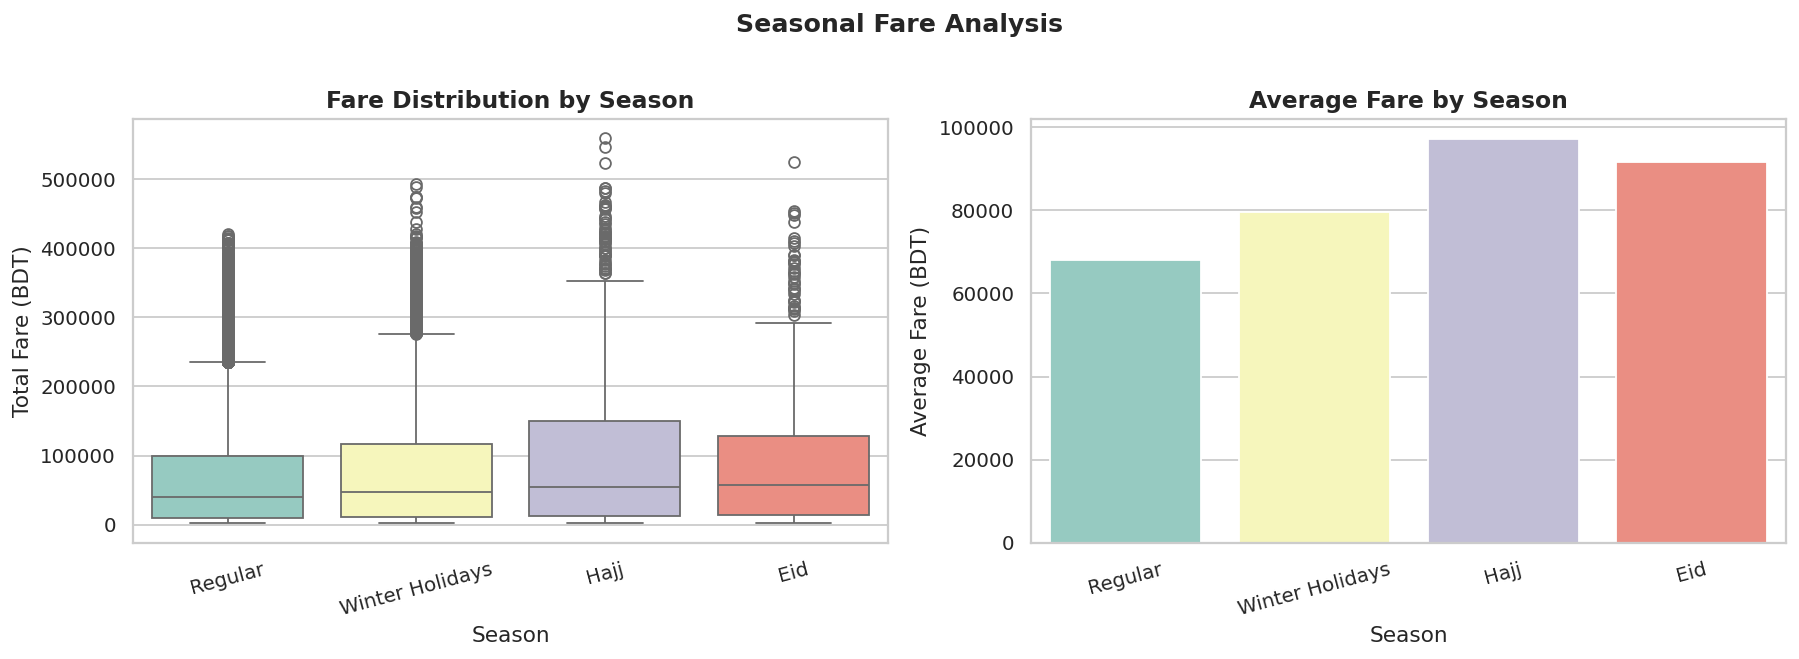

In [ ]:
season_col   = 'seasonality' if 'seasonality' in df.columns else 'season_derived'
season_order = df[season_col].value_counts().index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x=season_col, y='total_fare', order=season_order, palette='Set3', ax=axes[0])
axes[0].set_title('Fare Distribution by Season')
axes[0].set_xlabel('Season')
axes[0].set_ylabel('Total Fare (BDT)')
axes[0].tick_params(axis='x', rotation=15)

avg_season = df.groupby(season_col)['total_fare'].mean().reindex(season_order).reset_index()
sns.barplot(data=avg_season, x=season_col, y='total_fare', palette='Set3', ax=axes[1])
axes[1].set_title('Average Fare by Season')
axes[1].set_xlabel('Season')
axes[1].set_ylabel('Average Fare (BDT)')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Seasonal Fare Analysis', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 5.5 Monthly Fare Trend

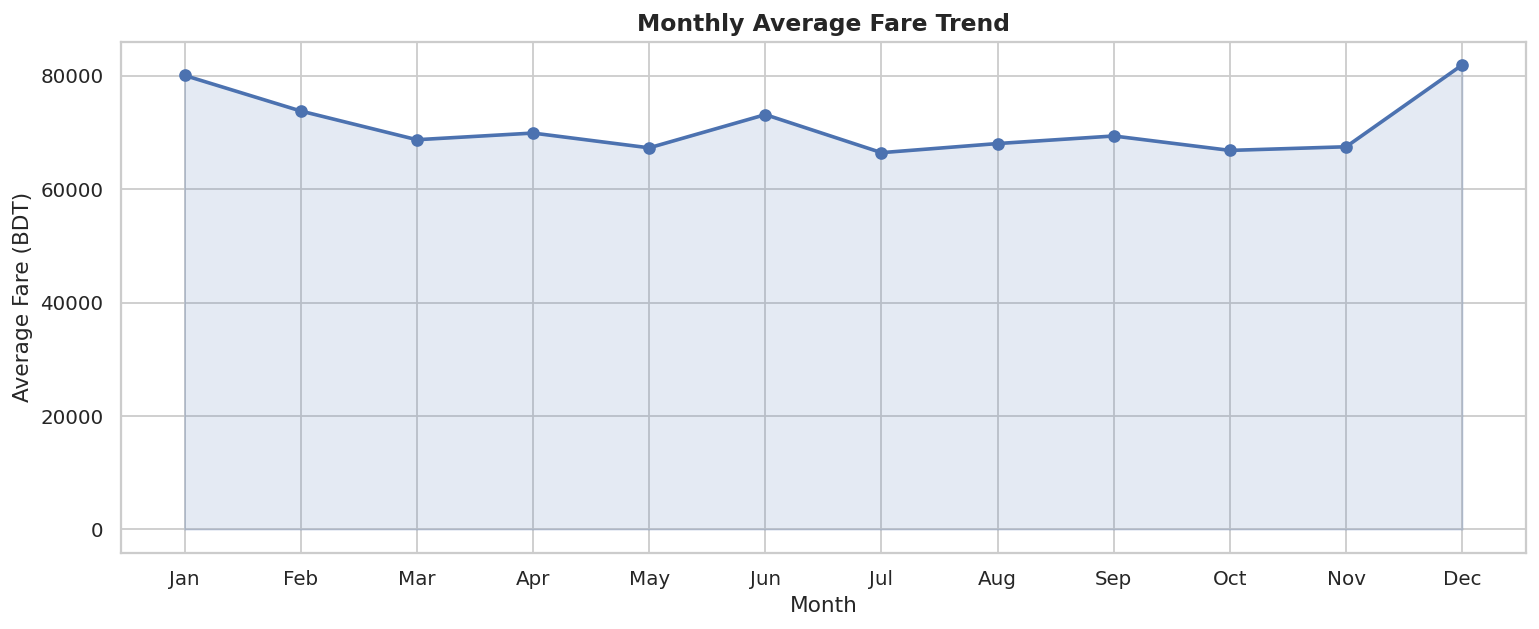

In [ ]:
monthly      = df.groupby('month')['total_fare'].mean().reset_index()
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly['month'], monthly['total_fare'], marker='o', linewidth=2, color='#4C72B0')
ax.fill_between(monthly['month'], monthly['total_fare'], alpha=0.15, color='#4C72B0')
ax.set_xticks(monthly['month'])
ax.set_xticklabels([month_labels[m - 1] for m in monthly['month']])
ax.set_title('Monthly Average Fare Trend')
ax.set_xlabel('Month')
ax.set_ylabel('Average Fare (BDT)')
plt.tight_layout()
plt.show()

### 5.6 Top Routes Analysis

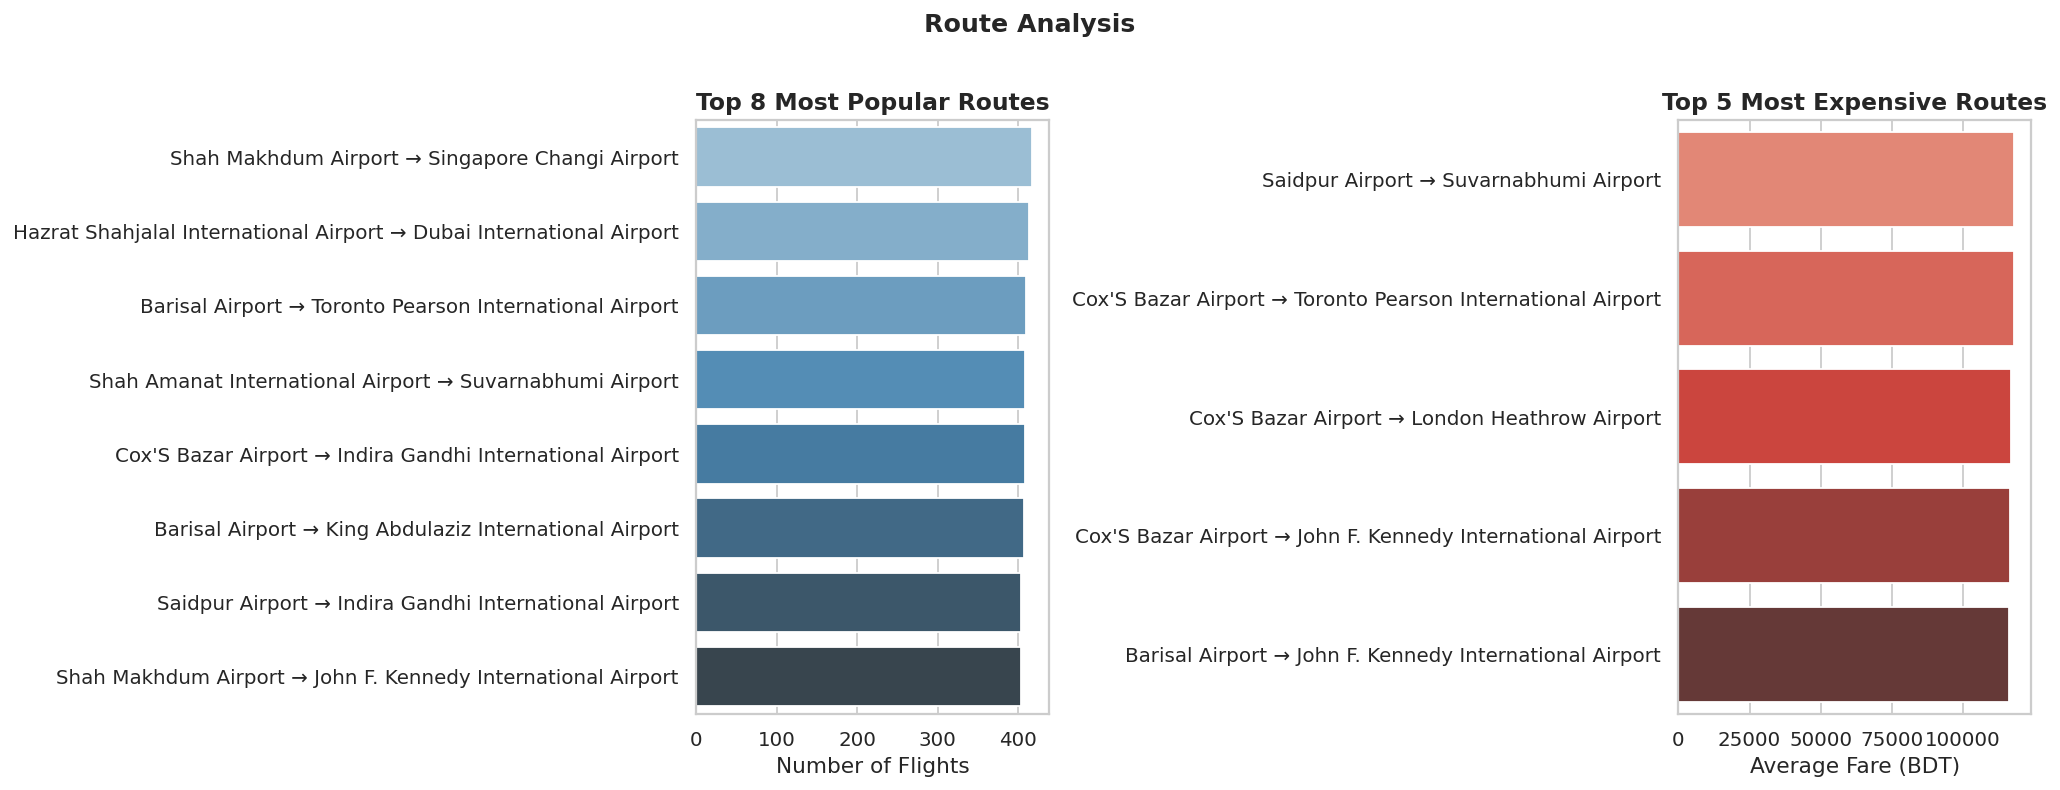

In [ ]:
df['route'] = df['source_name'].str.split(',').str[0] + ' → ' + df['destination_name'].str.split(',').str[0]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

popular = df['route'].value_counts().head(8).reset_index()
popular.columns = ['route', 'count']
sns.barplot(data=popular, x='count', y='route', palette='Blues_d', ax=axes[0])
axes[0].set_title('Top 8 Most Popular Routes')
axes[0].set_xlabel('Number of Flights')
axes[0].set_ylabel('')

expensive = (
    df.groupby('route')['total_fare']
    .mean()
    .sort_values(ascending=False)
    .head(5)
    .reset_index()
)
sns.barplot(data=expensive, x='total_fare', y='route', palette='Reds_d', ax=axes[1])
axes[1].set_title('Top 5 Most Expensive Routes')
axes[1].set_xlabel('Average Fare (BDT)')
axes[1].set_ylabel('')

plt.suptitle('Route Analysis', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 5.7 Fare by Booking Source & Stopovers

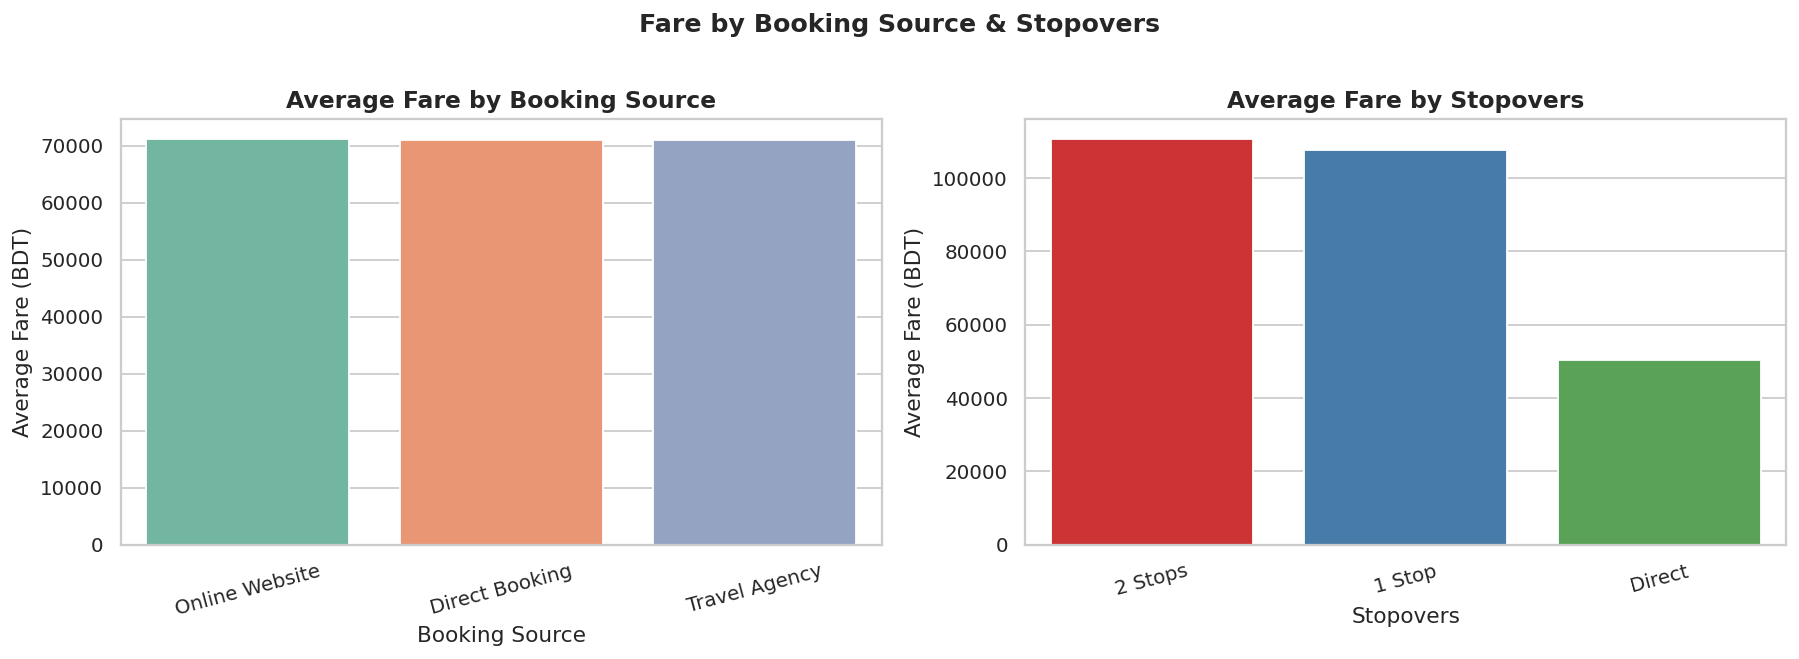

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if 'booking_source' in df.columns:
    avg_booking = df.groupby('booking_source')['total_fare'].mean().sort_values(ascending=False).reset_index()
    sns.barplot(data=avg_booking, x='booking_source', y='total_fare', palette='Set2', ax=axes[0])
    axes[0].set_title('Average Fare by Booking Source')
    axes[0].set_xlabel('Booking Source')
    axes[0].set_ylabel('Average Fare (BDT)')
    axes[0].tick_params(axis='x', rotation=15)

if 'stopovers' in df.columns:
    avg_stop = df.groupby('stopovers')['total_fare'].mean().sort_values(ascending=False).reset_index()
    sns.barplot(data=avg_stop, x='stopovers', y='total_fare', palette='Set1', ax=axes[1])
    axes[1].set_title('Average Fare by Stopovers')
    axes[1].set_xlabel('Stopovers')
    axes[1].set_ylabel('Average Fare (BDT)')
    axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Fare by Booking Source & Stopovers', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 5.8 Days Before Departure vs Fare

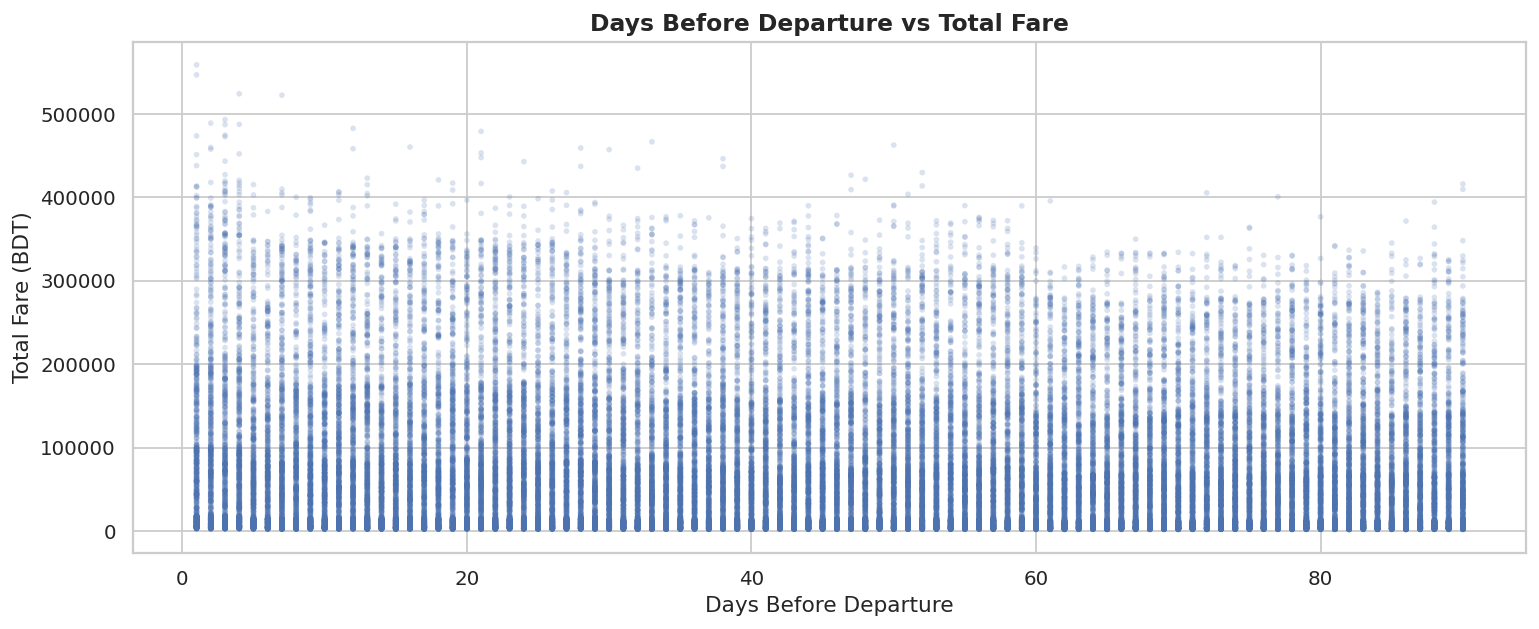

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.scatter(df['days_before_departure'], df['total_fare'], alpha=0.2, color='#4C72B0', edgecolors='none', s=10)
ax.set_title('Days Before Departure vs Total Fare')
ax.set_xlabel('Days Before Departure')
ax.set_ylabel('Total Fare (BDT)')
plt.tight_layout()
plt.show()

### 5.9 Correlation Heatmap

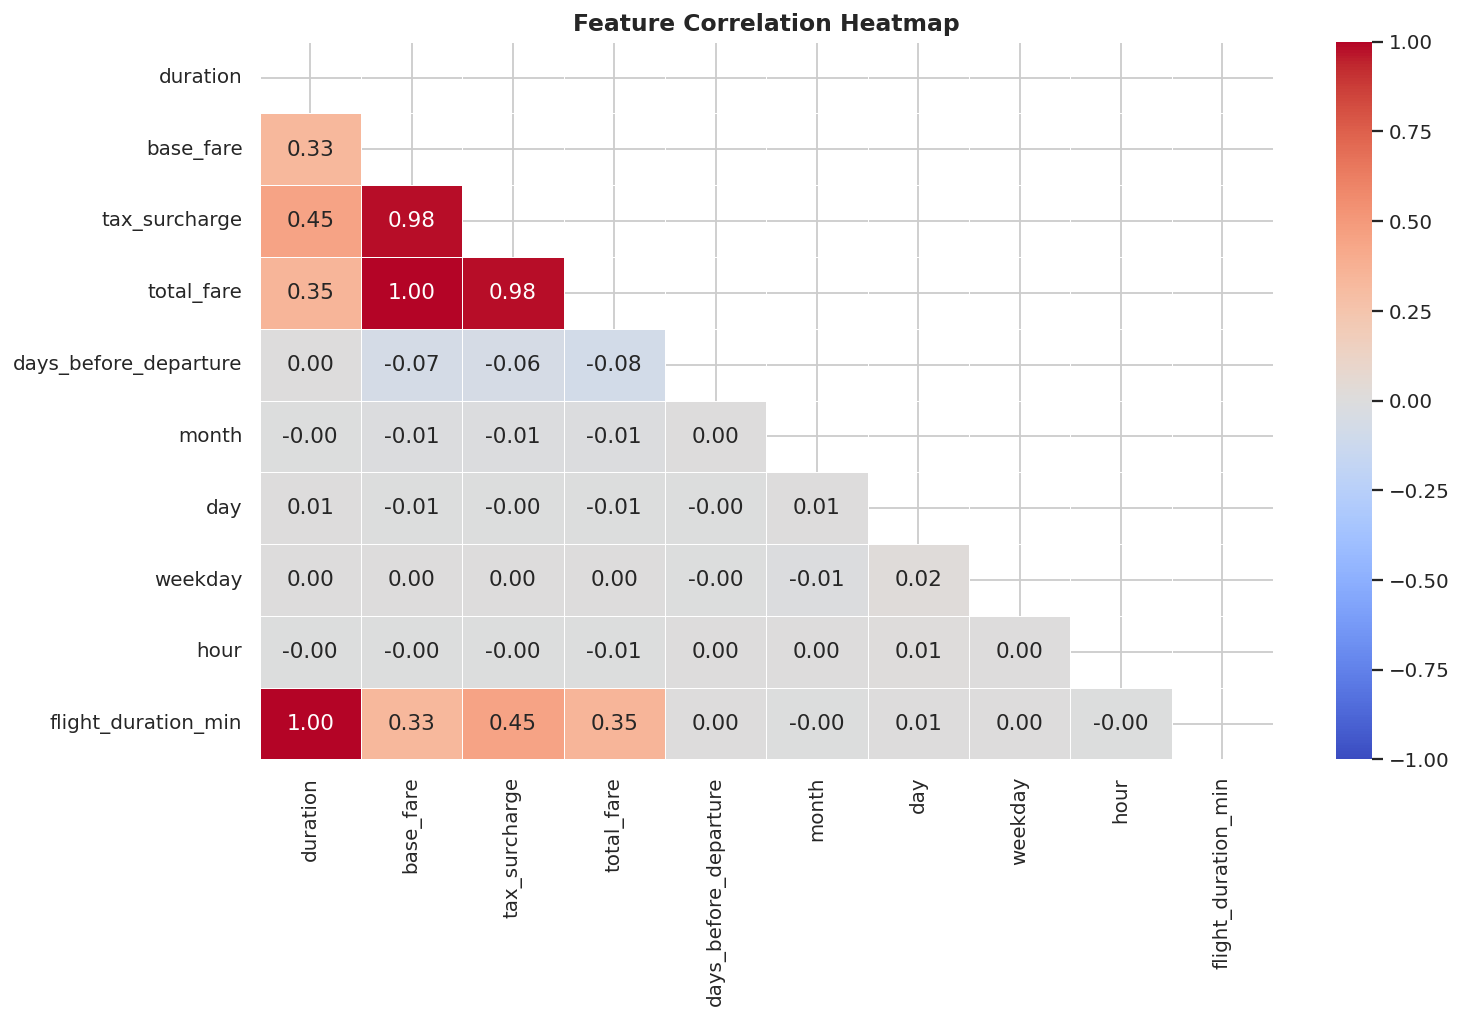

In [ ]:
numeric_df = df.select_dtypes(include=[np.number])
corr       = numeric_df.corr()
mask       = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', linewidths=0.5, vmin=-1, vmax=1, ax=ax
)
ax.set_title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

## 6. Model Preparation

In [ ]:
drop_cols = ['route', 'source_name', 'destination_name']
df_model  = df.drop(columns=drop_cols, errors='ignore')

cat_cols  = df_model.select_dtypes(include='object').columns.tolist()
df_model  = pd.get_dummies(df_model, columns=cat_cols, drop_first=True)

X = df_model.drop(columns=['total_fare'])
y = df_model['total_fare']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'Train    : {X_train_s.shape}')
print(f'Test     : {X_test_s.shape}')
print(f'Features : {X.shape[1]}')

Train    : (45600, 48)
Test     : (11400, 48)
Features : 48


## 7. Evaluation Helper

In [ ]:
def evaluate(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    r2     = r2_score(y_te, y_pred)
    mae    = mean_absolute_error(y_te, y_pred)
    rmse   = np.sqrt(mean_squared_error(y_te, y_pred))
    cv     = cross_val_score(model, X_tr, y_tr, cv=3, scoring='r2', n_jobs=-1).mean()
    print(f'{name:<22}  R²={r2:.4f}  MAE={mae:,.2f}  RMSE={rmse:,.2f}  CV-R²={cv:.4f}')
    return {'model': name, 'r2': r2, 'mae': mae, 'rmse': rmse, 'cv_r2': cv,
            'fitted': model, 'y_pred': y_pred}

## 8. Baseline Model — Linear Regression

In [ ]:
print('Training LinearRegression...')
baseline = evaluate('LinearRegression', LinearRegression(), X_train_s, y_train, X_test_s, y_test)
print('Done.')

Training LinearRegression...
LinearRegression        R²=0.9969  MAE=1,698.31  RMSE=4,553.08  CV-R²=0.9967
Done.


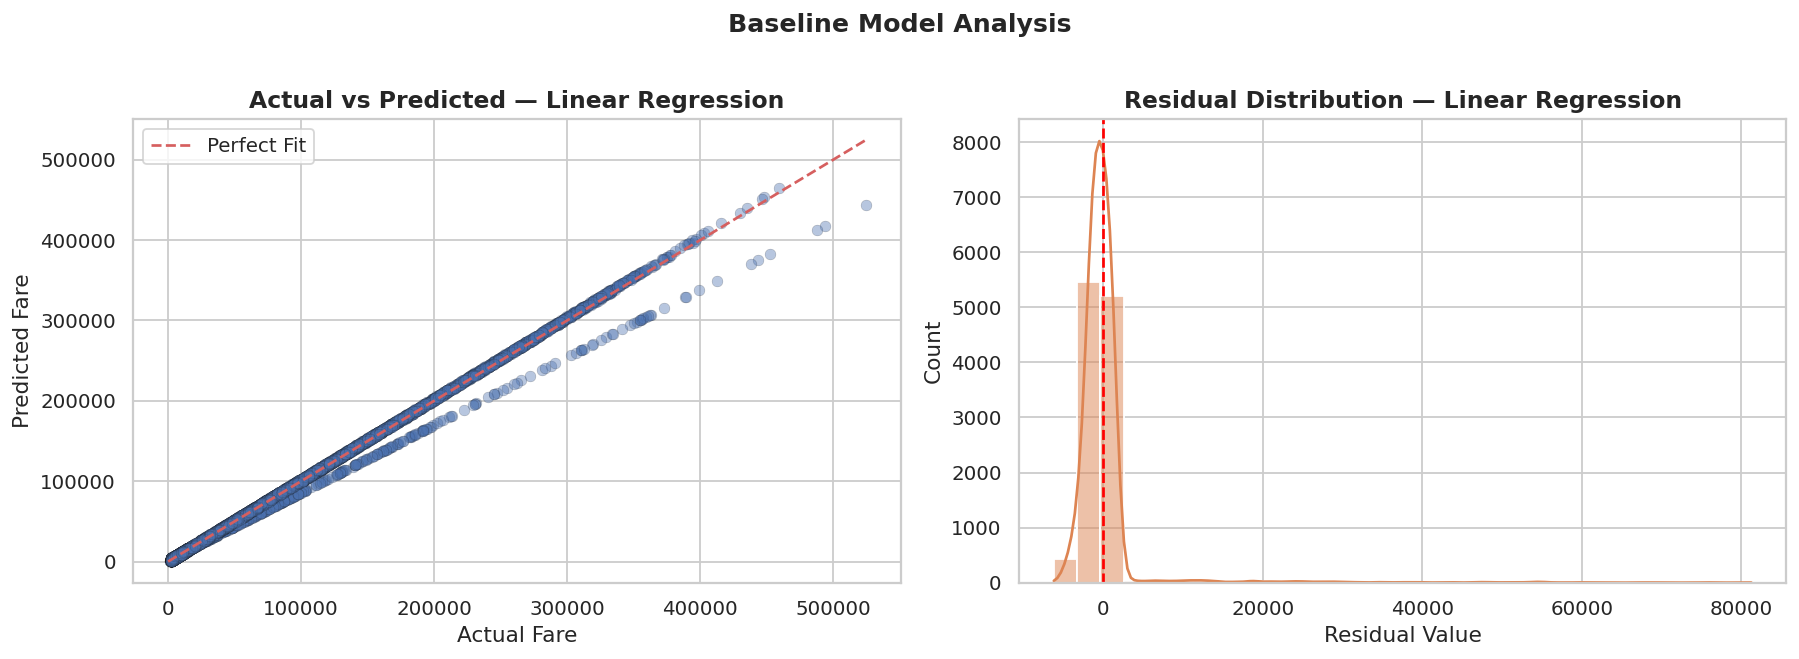

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, baseline['y_pred'], alpha=0.4, color='#4C72B0', edgecolors='k', linewidths=0.2)
lims = [min(y_test.min(), baseline['y_pred'].min()), max(y_test.max(), baseline['y_pred'].max())]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Perfect Fit')
axes[0].set_title('Actual vs Predicted — Linear Regression')
axes[0].set_xlabel('Actual Fare')
axes[0].set_ylabel('Predicted Fare')
axes[0].legend()

residuals = y_test.values - baseline['y_pred']
sns.histplot(residuals, bins=30, kde=True, color='#DD8452', ax=axes[1])
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_title('Residual Distribution — Linear Regression')
axes[1].set_xlabel('Residual Value')

plt.suptitle('Baseline Model Analysis', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 9. Advanced Models & Hyperparameter Tuning

In [ ]:
param_grids = {
    'Ridge':            {'alpha': [1.0, 10.0, 100.0]},
    'Lasso':            {'alpha': [1.0, 10.0, 100.0]},
    'DecisionTree':     {'max_depth': [10, 20], 'min_samples_split': [2, 5]},
    'RandomForest':     {'n_estimators': [50], 'max_depth': [10, 20]},
    'GradientBoosting': {'n_estimators': [50], 'learning_rate': [0.1], 'max_depth': [3, 5]},
}

models = {
    'Ridge':            Ridge(),
    'Lasso':            Lasso(max_iter=10000),
    'DecisionTree':     DecisionTreeRegressor(random_state=RANDOM_STATE),
    'RandomForest':     RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    'GradientBoosting': GradientBoostingRegressor(random_state=RANDOM_STATE),
}

all_results = [baseline]

for name, model in models.items():
    print(f'Training {name}...')
    gs = GridSearchCV(model, param_grids[name], cv=3, scoring='r2', n_jobs=-1)
    gs.fit(X_train_s, y_train)
    result = evaluate(name, gs.best_estimator_, X_train_s, y_train, X_test_s, y_test)
    result['best_params'] = gs.best_params_
    all_results.append(result)
    print(f'Best params: {gs.best_params_}\n')

print('All models trained successfully.')

Training Ridge...
Ridge                   R²=0.9969  MAE=1,697.97  RMSE=4,552.83  CV-R²=0.9967
Best params: {'alpha': 1.0}

Training Lasso...
Lasso                   R²=0.9969  MAE=1,686.82  RMSE=4,551.91  CV-R²=0.9967
Best params: {'alpha': 10.0}

Training DecisionTree...
DecisionTree            R²=0.9997  MAE=83.42  RMSE=1,291.57  CV-R²=0.9999
Best params: {'max_depth': 20, 'min_samples_split': 2}

Training RandomForest...
RandomForest            R²=0.9999  MAE=59.08  RMSE=963.90  CV-R²=0.9999
Best params: {'max_depth': 20, 'n_estimators': 50}

Training GradientBoosting...
GradientBoosting        R²=0.9999  MAE=447.01  RMSE=907.96  CV-R²=0.9999
Best params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 50}

All models trained successfully.


## 10. Model Comparison

In [ ]:
results_df = pd.DataFrame([
    {'Model': r['model'], 'R²': round(r['r2'], 4), 'MAE': round(r['mae'], 2),
     'RMSE': round(r['rmse'], 2), 'CV R²': round(r['cv_r2'], 4)}
    for r in all_results
]).sort_values('R²', ascending=False).reset_index(drop=True)

print('Model Comparison Table:')
results_df

Model Comparison Table:


,Model,R²,MAE,RMSE,CV R²
0,RandomForest,0.9999,59.08,963.90,0.9999
1,GradientBoosting,0.9999,447.01,907.96,0.9999
2,DecisionTree,0.9997,83.42,1291.57,0.9999
3,LinearRegression,0.9969,1698.31,4553.08,0.9967
4,Ridge,0.9969,1697.97,4552.83,0.9967
5,Lasso,0.9969,1686.82,4551.91,0.9967


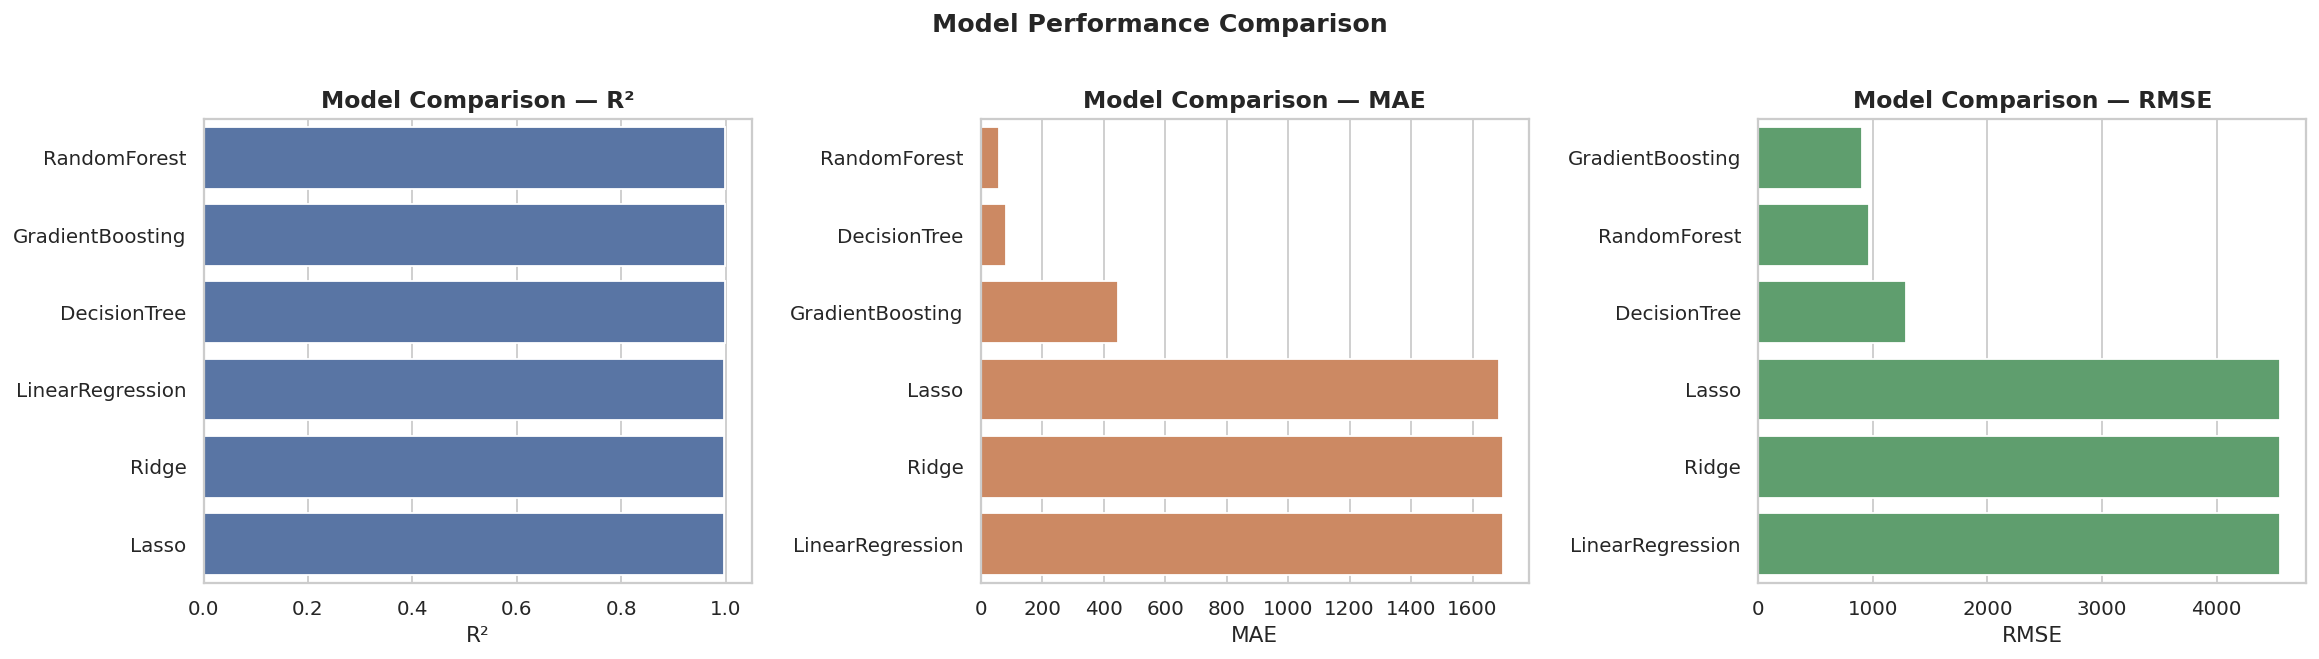

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics   = [('R²', True), ('MAE', False), ('RMSE', False)]
colors    = ['#4C72B0', '#DD8452', '#55A868']

for ax, (metric, higher_better), color in zip(axes, metrics, colors):
    sorted_df = results_df.sort_values(metric, ascending=not higher_better)
    sns.barplot(data=sorted_df, x=metric, y='Model', color=color, ax=ax)
    ax.set_title(f'Model Comparison — {metric}')
    ax.set_xlabel(metric)
    ax.set_ylabel('')

plt.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 11. Best Model — Feature Importance

Best Model : GradientBoosting
R²         : 0.9999
MAE        : 447.01 BDT
RMSE       : 907.96 BDT


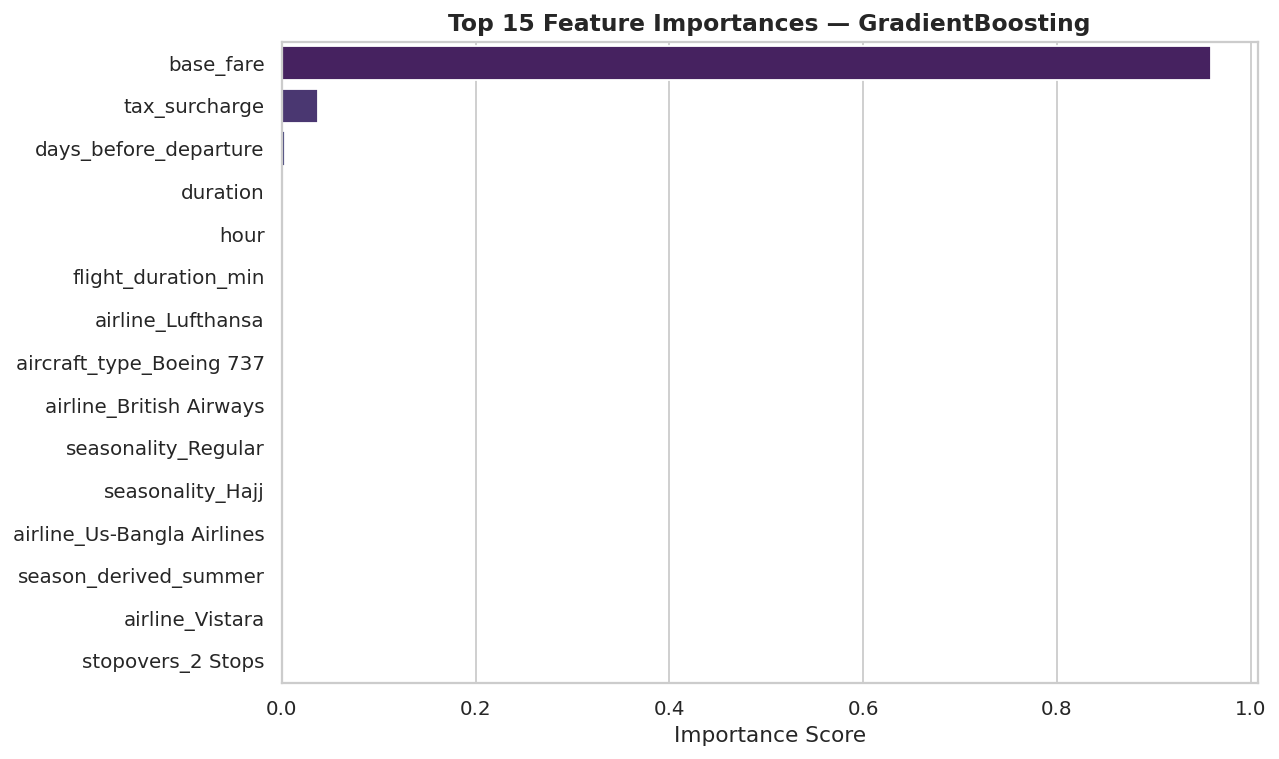

In [ ]:
best_result = max(all_results, key=lambda x: x['r2'])
best_model  = best_result['fitted']
best_name   = best_result['model']

print(f'Best Model : {best_name}')
print(f'R²         : {best_result["r2"]:.4f}')
print(f'MAE        : {best_result["mae"]:,.2f} BDT')
print(f'RMSE       : {best_result["rmse"]:,.2f} BDT')

if hasattr(best_model, 'feature_importances_'):
    importance = best_model.feature_importances_
elif hasattr(best_model, 'coef_'):
    importance = np.abs(best_model.coef_)
else:
    importance = None

if importance is not None:
    fi_df = (
        pd.DataFrame({'Feature': X.columns, 'Importance': importance})
        .sort_values('Importance', ascending=False)
        .head(15)
    )
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.barplot(data=fi_df, x='Importance', y='Feature', palette='viridis', ax=ax)
    ax.set_title(f'Top 15 Feature Importances — {best_name}')
    ax.set_xlabel('Importance Score')
    ax.set_ylabel('')
    plt.tight_layout()
    plt.show()
else:
    print(f'{best_name} does not support feature importance extraction.')

## 12. Best Model — Residual Analysis

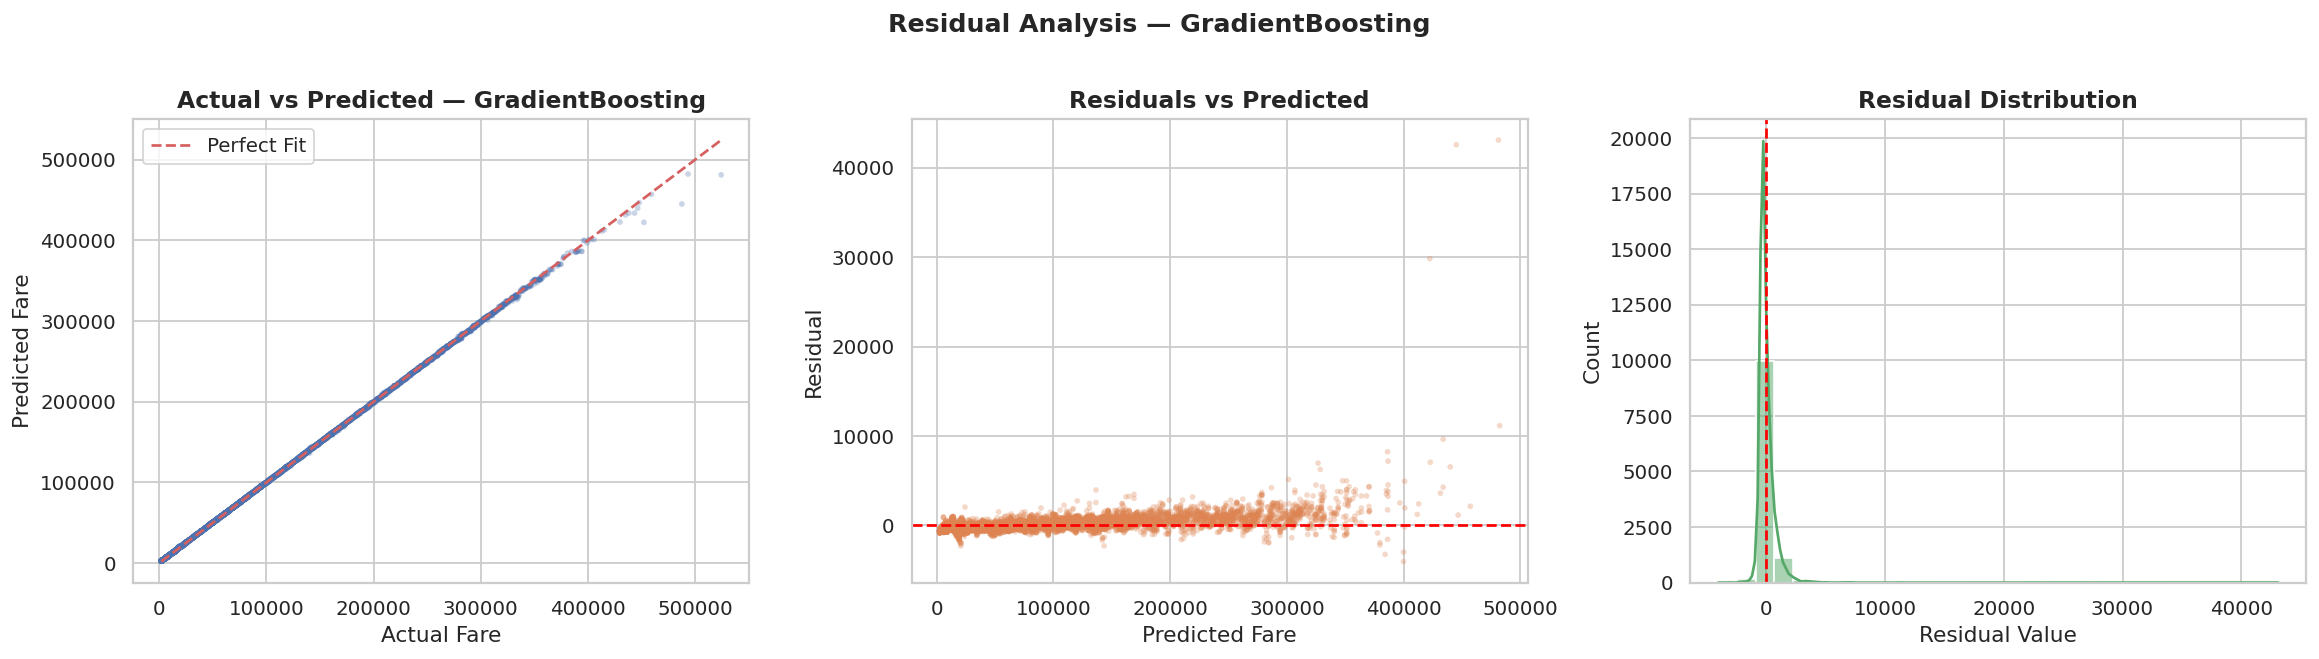

In [ ]:
y_pred_best = best_result['y_pred']
residuals   = y_test.values - y_pred_best

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(y_test, y_pred_best, alpha=0.3, color='#4C72B0', edgecolors='none', s=10)
lims = [min(y_test.min(), y_pred_best.min()), max(y_test.max(), y_pred_best.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Perfect Fit')
axes[0].set_title(f'Actual vs Predicted — {best_name}')
axes[0].set_xlabel('Actual Fare')
axes[0].set_ylabel('Predicted Fare')
axes[0].legend()

axes[1].scatter(y_pred_best, residuals, alpha=0.3, color='#DD8452', edgecolors='none', s=10)
axes[1].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_title('Residuals vs Predicted')
axes[1].set_xlabel('Predicted Fare')
axes[1].set_ylabel('Residual')

sns.histplot(residuals, bins=30, kde=True, color='#55A868', ax=axes[2])
axes[2].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[2].set_title('Residual Distribution')
axes[2].set_xlabel('Residual Value')

plt.suptitle(f'Residual Analysis — {best_name}', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 13. Regularization — Ridge vs Lasso

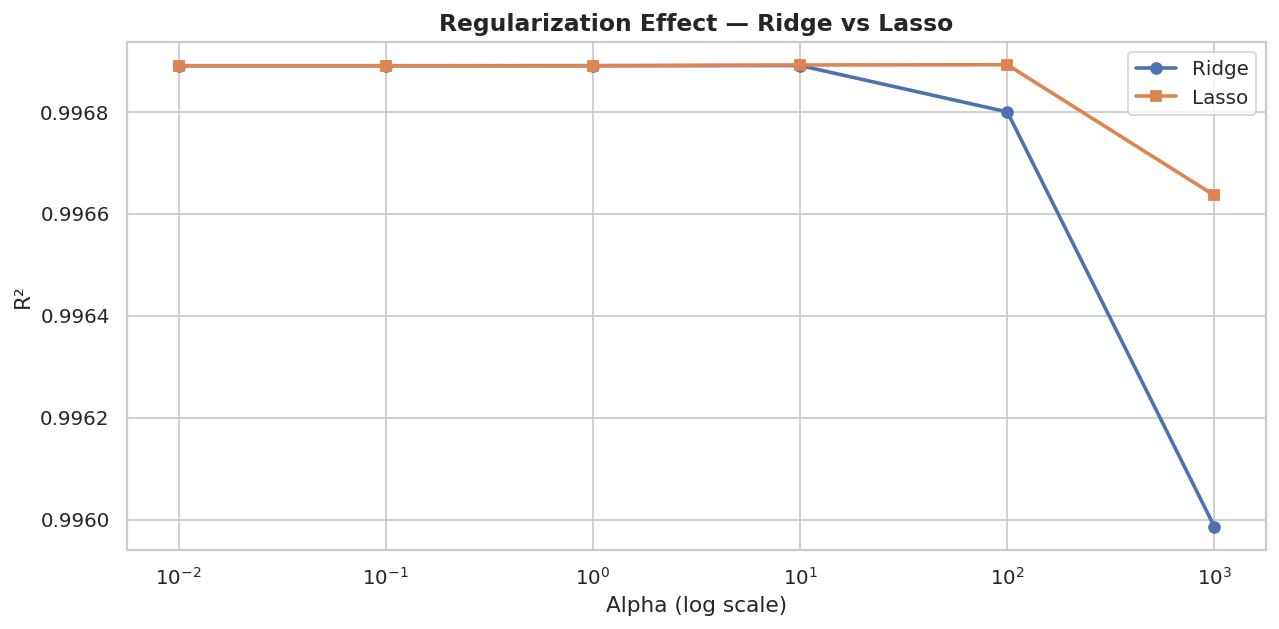

In [ ]:
alphas   = [0.01, 0.1, 1, 10, 100, 1000]
ridge_r2 = [r2_score(y_test, Ridge(alpha=a).fit(X_train_s, y_train).predict(X_test_s)) for a in alphas]
lasso_r2 = [r2_score(y_test, Lasso(alpha=a, max_iter=10000).fit(X_train_s, y_train).predict(X_test_s)) for a in alphas]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(alphas, ridge_r2, marker='o', label='Ridge', color='#4C72B0', linewidth=2)
ax.plot(alphas, lasso_r2, marker='s', label='Lasso', color='#DD8452', linewidth=2)
ax.set_xscale('log')
ax.set_title('Regularization Effect — Ridge vs Lasso')
ax.set_xlabel('Alpha (log scale)')
ax.set_ylabel('R²')
ax.legend()
plt.tight_layout()
plt.show()

## 14. Key Insights & Recommendations

**Fare Drivers:**
- `base_fare` and `tax_surcharge` are the strongest predictors of total fare.
- Travel class, airline, and route significantly influence pricing.
- `days_before_departure` shows a clear relationship with fare — booking earlier tends to yield lower prices.

**Airline Insights:**
- Premium airlines consistently price higher on the same routes.
- Economy class routes show the highest frequency but lowest average fares.

**Seasonal Insights:**
- Winter Holiday and Eid seasons show the highest average fares.
- Regular season offers the most competitive pricing.

**Recommendations:**
- Travelers should book at least 14 days in advance to secure lower fares.
- Off-peak seasons offer significant savings compared to holiday periods.
- Direct flights are not always cheaper — stopovers can sometimes reduce total fare.